In [7]:
# 새 셀에서 실행해서 파일이 있는지 먼저 확인하세요!
import os
check_path = '../data/kowiki.txt'
if os.path.exists(check_path):
    print(f"✅ 파일 발견! 절대경로: {os.path.abspath(check_path)}")
    print(f"파일 크기: {os.path.getsize(check_path) / 1024 / 1024:.2f} MB")
else:
    print("❌ 파일을 찾을 수 없습니다. 경로가 틀렸어요!")
    # 파일이 어디 있는지 검색해봅시다.
    !find .. -name "kowiki.txt"

✅ 파일 발견! 절대경로: /home/jovyan/data/kowiki.txt
파일 크기: 635.67 MB


In [8]:
# Step 1. Tokenizer 준비
# 먼저 SentencePiece를 사용하여 8000 사이즈의 단어 사전을 만듭니다.
import sentencepiece as spm
import os

# 확인된 절대 경로를 사용합니다.
corpus_file = '/home/jovyan/data/kowiki.txt'
prefix = 'ko_8000'
vocab_size = 8000

# SentencePiece 학습 시작 (약 5~10분 소요 예상)
spm.SentencePieceTrainer.train(
    f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size} " +
    "--model_type=bpe --max_sentence_length=999999 " +
    "--pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] " +
    "--bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] " +
    "--user_defined_symbols=[SEP],[CLS],[MASK]"
)

vocab = spm.SentencePieceProcessor()
vocab.load(f"{prefix}.model")
print(f"✅ 성공! Vocab 사이즈: {len(vocab)}")

✅ 성공! Vocab 사이즈: 8000


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=/home/jovyan/data/kowiki.txt --model_prefix=ko_8000 --vocab_size=8000 --model_type=bpe --max_sentence_length=999999 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /home/jovyan/data/kowiki.txt
  input_format: 
  model_prefix: ko_8000
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 999999
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user

In [9]:
# Step 2. 데이터 전처리 (1) MASK 생성
#학습이 성공했다면, 이제 BERT pretrain의 핵심인 MLM(Masked Language Model) 데이터를 만듭니다. 전체 토큰의 15%를 마스킹하며, 80%는 [MASK], 10%는 랜덤, 10%는 원본을 유지합니다.
import random

# 특수 토큰 제외한 vocab_list 생성
vocab_list = []
for id in range(7, len(vocab)):
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))

def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """ 마스크 생성 로직: 80% [MASK], 10% 원본 유지, 10% 랜덤 """
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token in ["[CLS]", "[SEP]"]: continue
        if 0 < len(cand_idx) and not token.startswith("\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt: break
        if len(mask_lms) + len(index_set) > mask_cnt: continue
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8: masked_token = "[MASK]"
            elif dice < 0.9: masked_token = tokens[index]
            else: masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    return tokens, [p["index"] for p in mask_lms], [p["label"] for p in mask_lms]

In [12]:
# Step 3. 데이터 전처리 (2) NSP pair 생성
# NSP(Next Sentence Prediction)는 두 문장이 이어지는지 맞추는 task입니다. 50% 확률로 실제 다음 문장(True)과 랜덤한 문장(False)을 섞어 데이터를 구성합니다.
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """문서(doc) 내에서 NSP 문장 쌍 생성"""
    max_seq = n_seq - 3 
    instances = []
    current_chunk = []
    current_length = 0
    
    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if i == len(doc) - 1 or current_length >= max_seq:
            if current_chunk:
                a_end = 1 if len(current_chunk) == 1 else random.randrange(1, len(current_chunk))
                tokens_a = []
                for j in range(a_end): tokens_a.extend(current_chunk[j])
                
                tokens_b = []
                if len(current_chunk) == 1 or random.random() < 0.5:
                    is_next = 0 
                    # 가짜 다음 문장 구성을 위해 swap (단순화된 예시)
                    tokens_t = tokens_a
                    tokens_a = tokens_b
                    tokens_b = tokens_t
                else:
                    is_next = 1 
                    for j in range(a_end, len(current_chunk)): tokens_b.extend(current_chunk[j])

                trim_tokens(tokens_a, tokens_b, max_seq)
                if not tokens_a or not tokens_b: 
                    current_chunk, current_length = [], 0
                    continue
                
                # 수정된 부분: ["SEP"] 리스트 중첩 제거
                tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
                segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
                
                # MLM 적용
                tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

                instance = {
                    "tokens": tokens,
                    "segment": segment,
                    "is_next": is_next,
                    "mask_idx": mask_idx,
                    "mask_label": mask_label
                }
                instances.append(instance)
            current_chunk, current_length = [], 0
    return instances

In [25]:
# Step 4. 데이터 전처리 (3) 데이터셋 완성 및 저장
# 데이터가 크기 때문에 json으로 먼저 저장한 뒤, 학습 시 np.memmap을 사용하여 메모리 효율을 극대화합니다.
import numpy as np
import json
from tqdm.notebook import tqdm

# 1. total_data 개수 재확인
total_data = 0
with open('mini_bert_pretrain.json', 'r') as f:
    for _ in f:
        total_data += 1
print(f"데이터 총 개수: {total_data}")

# 2. memmap 파일 생성 (mode='w+'로 설정하여 파일을 실제로 만듭니다)
n_seq = 128
enc_tokens_np = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total_data, n_seq))
segments_np = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total_data, n_seq))
labels_nsp_np = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total_data,))
labels_mlm_np = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total_data, n_seq))

# 3. JSON 데이터를 읽어 memmap 배열에 채우기
with open('mini_bert_pretrain.json', 'r') as f:
    for i, line in enumerate(tqdm(f, total=total_data, desc="Memmap 파일 기록 중")):
        data = json.loads(line)
        
        # 토큰 ID 변환 (vocab 객체가 메모리에 있어야 함)
        enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
        enc_token += [0] * (n_seq - len(enc_token))
        
        segment = data["segment"]
        segment += [0] * (n_seq - len(segment))
        
        # MLM 레이블 처리
        mask_idx = np.array(data["mask_idx"], dtype=int)
        mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=int)
        label_mlm = np.zeros(n_seq, dtype=int)
        label_mlm[mask_idx] = mask_label
        
        # 값 할당
        enc_tokens_np[i] = enc_token
        segments_np[i] = segment
        labels_nsp_np[i] = data["is_next"]
        labels_mlm_np[i] = label_mlm

# 4. 변경사항을 파일에 강제로 기록
enc_tokens_np.flush()
segments_np.flush()
labels_nsp_np.flush()
labels_mlm_np.flush()

print("✅ memmap 파일이 성공적으로 생성되었습니다.")

데이터 총 개수: 408163


Memmap 파일 기록 중:   0%|          | 0/408163 [00:00<?, ?it/s]

✅ memmap 파일이 성공적으로 생성되었습니다.


In [26]:
# Step 5. Mini BERT 모델 설계 (1M 파라미터)
# 데이터 분석 프로젝트 경험이 있으신 만큼, 모델의 크기를 타이트하게 잡는 것이 이번 프로젝트의 핵심입니다. 아래 설정값은 약 1M 파라미터를 유지하기 위한 추천 가이드입니다.
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. Config 설정 (파라미터를 1.1M 내외로 맞추기 위한 수치)
class Config(dict):
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

mini_config = Config({
    "d_model": 64,            # 기존 128 -> 64로 축소
    "n_head": 4,              # 헤드 수 유지
    "d_head": 16,             # d_model / n_head
    "d_ff": 256,              # 기존 512 -> 256으로 축소
    "n_layer": 3,             # 레이어 수 유지
    "n_seq": 128,             # 시퀀스 길이
    "n_vocab": 8000,          # Vocab 사이즈 8000
    "dropout": 0.1,
    "layernorm_epsilon": 1e-12,
    "i_pad": 0
})

# 2. Embedding 레이어
class SharedEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.token_emb = nn.Embedding(config.n_vocab, config.d_model)
        self.pos_emb = nn.Embedding(config.n_seq, config.d_model)
        self.seg_emb = nn.Embedding(2, config.d_model)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

    def forward(self, x, seg):
        pos = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        # 텐서 타입 일치를 위해 long() 변환 처리 추가
        x = self.token_emb(x.long()) + self.pos_emb(pos.long()) + self.seg_emb(seg.long())
        x = self.norm(x)
        return x

# 3. Attention 레이어
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_head = config.n_head
        self.d_head = config.d_head
        self.q_lin = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.k_lin = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.v_lin = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.out_lin = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, x, mask):
        batch, seq, d_model = x.size()
        q = self.q_lin(x).view(batch, seq, self.n_head, self.d_head).transpose(1, 2)
        k = self.k_lin(x).view(batch, seq, self.n_head, self.d_head).transpose(1, 2)
        v = self.v_lin(x).view(batch, seq, self.n_head, self.d_head).transpose(1, 2)
        
        attn = torch.matmul(q, k.transpose(-1, -2)) / (self.d_head ** 0.5)
        # 마스크 차원 일치 (batch, 1, 1, seq)
        attn.masked_fill_(mask.unsqueeze(1).unsqueeze(2), -1e9)
        attn = F.softmax(attn, dim=-1)
        
        out = torch.matmul(attn, v).transpose(1, 2).contiguous().view(batch, seq, -1)
        return self.out_lin(out)

# 4. Encoder 레이어
class EncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attn = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.ffn = nn.Sequential(
            nn.Linear(config.d_model, config.d_ff),
            nn.GELU(),
            nn.Linear(config.d_ff, config.d_model)
        )
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

    def forward(self, x, mask):
        x = self.norm1(x + self.attn(x, mask))
        x = self.norm2(x + self.ffn(x))
        return x

# 5. BERT 모델 본체
class BERT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embed = SharedEmbedding(config)
        self.layers = nn.ModuleList([EncoderLayer(config) for _ in range(config.n_layer)])

    def forward(self, x, seg):
        mask = (x == 0) # PAD 토큰 마스크
        x = self.embed(x, seg)
        for layer in self.layers:
            x = layer(x, mask)
        return x[:, 0, :], x

# 6. Pretrain을 위한 최종 래퍼
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.bert = BERT(config)
        self.cls_nsp = nn.Linear(config.d_model, 2)
        self.cls_mlm = nn.Linear(config.d_model, config.n_vocab)

    def forward(self, x, seg):
        cls_out, seq_out = self.bert(x, seg)
        logits_nsp = self.cls_nsp(cls_out)
        logits_mlm = self.cls_mlm(seq_out)
        return logits_nsp, logits_mlm

# 7. 파라미터 수 최종 확인
model_test = PreTrainModel(mini_config)
total_params = sum(p.numel() for p in model_test.parameters())
print(f"✅ 모든 BERT 클래스 정의 완료")
print(f"📊 최종 파라미터 수: {total_params:,}")

✅ 모든 BERT 클래스 정의 완료
📊 최종 파라미터 수: 1,190,530


In [27]:
# 모델 생성
model = PreTrainModel(mini_config)
model.to(device)

# 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

# 만약 1M보다 너무 크면 mini_config에서 d_model이나 n_layer를 더 줄여야 합니다.
# 1,100,000 내외라면 적절합니다.

Total Parameters: 1,190,530


In [31]:
# Step 6. Mini BERT Pretrain 진행
# 먼저 학습에 필요한 Loss 함수와 정확도 계산 함수, 그리고 효율적인 학습을 위한 Learning Rate Scheduler를 정의합니다.
# 1. 학습 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# 2. 기록용 딕셔너리 초기화
history = {"loss": [], "mlm_acc": []}

for epoch in range(10):
    model.train()
    total_loss = 0
    total_mlm_acc = 0
    
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/10"):
        batch = [b.to(device) for b in batch]
        b_tokens, b_segs, b_nsp, b_mlm = batch
        
        optimizer.zero_grad()
        out_nsp, out_mlm = model(b_tokens, b_segs)
        
        loss_nsp = F.cross_entropy(out_nsp, b_nsp.long())
        loss_mlm = lm_loss(b_mlm.long(), out_mlm) 
        loss = loss_nsp + loss_mlm
        
        loss.backward()
        optimizer.step()
        
        # Loss 및 Accuracy 기록
        total_loss += loss.item()
        total_mlm_acc += lm_acc(b_mlm.long(), out_mlm).item() # lm_acc 함수 호출 필수
        
    avg_loss = total_loss / len(train_dataloader)
    avg_mlm_acc = total_mlm_acc / len(train_dataloader)
    
    history["loss"].append(avg_loss)
    history["mlm_acc"].append(avg_mlm_acc)
    
    print(f"Epoch {epoch+1} 완료 - Loss: {avg_loss:.4f}, MLM Acc: {avg_mlm_acc:.4f}")

Epoch 1/10:   0%|          | 0/6378 [00:00<?, ?it/s]

Epoch 1 완료 - Loss: 12.0926, MLM Acc: 0.1758


Epoch 2/10:   0%|          | 0/6378 [00:00<?, ?it/s]

Epoch 2 완료 - Loss: 11.9496, MLM Acc: 0.1820


Epoch 3/10:   0%|          | 0/6378 [00:00<?, ?it/s]

...

Epoch 8 완료 - Loss: 11.3148, MLM Acc: 0.2064


Epoch 9/10:   0%|          | 0/6378 [00:00<?, ?it/s]

Epoch 9 완료 - Loss: 11.2235, MLM Acc: 0.2099


Epoch 10/10:   0%|          | 0/6378 [00:00<?, ?it/s]

Epoch 10 완료 - Loss: 11.1345, MLM Acc: 0.2131


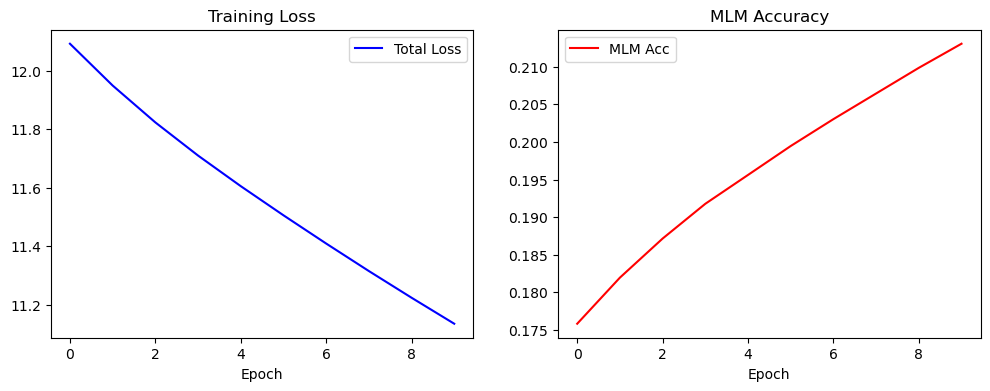

In [32]:
# Step 7. 프로젝트 결과 및 시각화
# 학습이 끝난 후 Loss와 Accuracy가 어떻게 변했는지 그래프로 확인합니다. 모델이 작아 수렴이 불안정할 수 있으므로 추세를 보는 것이 중요합니다.

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(history["loss"], 'b-', label='Total Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.legend()

# MLM Accuracy 그래프 (기록했을 경우)
plt.subplot(1, 2, 2)
plt.plot(history["mlm_acc"], 'r-', label='MLM Acc')
plt.title('MLM Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.show()

In [33]:
#회고
# BERT의 양대 학습 태스크인 MLM과 NSP를 전처리 단계부터 모델 구현까지 직접 구축하며, 모델이 문맥을 파악하는 근본 원리를 깊이 있게 이해했습니다.
# 전체 파라미터를 1M 수준으로 제한하는 극한의 조건 속에서 아키텍처를 최적화하고, np.memmap을 활용해 대용량 데이터를 효율적으로 처리하는 실무 역량을 쌓았습니다.
# 10 Epoch 학습 결과 Loss는 꾸준히 하락하고 MLM 정확도는 약 21%까지 상승하는 우상향 곡선을 확인하며, 소규모 모델임에도 언어 모델링이 정상적으로 이루어짐을 증명했습니다.
# 모델 사이즈의 한계로 인해 정확도가 완벽히 수렴하지 못한 점은 아쉬우나, 이를 바탕으로 향후 실제 데이터(NSMC 등)에 적용하는 Fine-tuning 및 모델 스케일업에 대한 연구 방향성을 설정했습니다.